In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import seaborn as sns
import statsmodels.formula.api as smf
import sklearn.linear_model as lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
df = pd.read_csv("student-mat.csv", sep = ';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
df.shape

(395, 33)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [8]:
X = df.drop('G3', axis=1)
Y = df['G3']

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
alphas = 10**np.linspace(10, -2, 100) * 0.5

In [13]:
ridgecv=RidgeCV(alphas=alphas)
ridgecv.fit(X,Y)
ridgecv.alpha_

np.float64(201.85086292982749)

In [12]:
lassocv=LassoCV(alphas=alphas)
lassocv.fit(X,Y)
lassocv.alpha_

np.float64(0.10772173450159389)

In [ ]:
fitL=Lasso(alpha=0.10772173450159389)
fitL.fit(X,Y)
print(pd.Series(fitL.coef_,index=X.columns))

age                 -0.129076
Medu                 0.000000
Fedu                -0.000000
traveltime           0.000000
studytime           -0.000000
failures            -0.000000
famrel               0.221223
freetime             0.000000
goout                0.000000
Dalc                 0.000000
Walc                 0.041326
health               0.009699
absences             0.038344
G1                   0.151267
G2                   0.979565
school_MS            0.000000
sex_M                0.000000
address_U           -0.000000
famsize_LE3          0.000000
Pstatus_T           -0.000000
Mjob_health         -0.000000
Mjob_other           0.000000
Mjob_services        0.000000
Mjob_teacher         0.000000
Fjob_health          0.000000
Fjob_other           0.000000
Fjob_services       -0.000000
Fjob_teacher         0.000000
reason_home         -0.000000
reason_other         0.000000
reason_reputation    0.000000
guardian_mother      0.000000
guardian_other      -0.000000
schoolsup_

In [14]:
fitR = Ridge(alpha=201.85086292982749)
fitR.fit(X, Y)
print(pd.Series(fitR.coef_,index=X.columns))

age                 -0.149233
Medu                 0.055669
Fedu                -0.053432
traveltime           0.038004
studytime           -0.065952
failures            -0.117057
famrel               0.204249
freetime             0.042186
goout                0.002914
Dalc                -0.035464
Walc                 0.083987
health               0.045311
absences             0.041075
G1                   0.241677
G2                   0.882448
school_MS            0.049397
sex_M                0.038680
address_U            0.004653
famsize_LE3          0.020278
Pstatus_T           -0.032643
Mjob_health         -0.005333
Mjob_other           0.022070
Mjob_services        0.014896
Mjob_teacher        -0.006988
Fjob_health          0.036849
Fjob_other           0.050022
Fjob_services       -0.075626
Fjob_teacher        -0.002963
reason_home         -0.073713
reason_other         0.048182
reason_reputation    0.033097
guardian_mother      0.061065
guardian_other      -0.028061
schoolsup_

In [ ]:
X_temp = X.astype(float)
X_temp = X_temp.replace([np.inf, -np.inf], np.nan)
X_temp = X_temp.dropna()
X_vif = pd.DataFrame()
X_vif["feature"] = X_temp.columns
X_vif["VIF"] = [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]

print(X_vif.sort_values(by='VIF', ascending=False))

              feature        VIF
0                 age  96.636256
13                 G1  55.135980
14                 G2  40.085601
6              famrel  23.209399
38         higher_yes  23.074867
1                Medu  21.446693
7            freetime  14.728739
2                Fedu  13.516089
8               goout  13.121780
25         Fjob_other  12.907035
19          Pstatus_T  10.897307
10               Walc   9.963482
4           studytime   9.602016
11             health   8.639272
9                Dalc   7.637577
39       internet_yes   7.420126
26      Fjob_services   7.008584
3          traveltime   6.660620
17          address_U   6.047766
37        nursery_yes   5.594778
31    guardian_mother   4.737578
21         Mjob_other   4.295158
22      Mjob_services   3.886372
23       Mjob_teacher   3.712347
34         famsup_yes   3.334179
27       Fjob_teacher   2.841863
16              sex_M   2.822230
20        Mjob_health   2.524866
35           paid_yes   2.463590
36     act

In [ ]:
drop_cols = [
    'Medu', 'Fedu', 'traveltime', 'health', 'Dalc',
    'address_U', 'famsize_LE3', 'Pstatus_T',
    'Mjob_health', 'Mjob_other', 'Mjob_services',
    'school_MS', 'sex_M', 'internet_yes',
    'higher_yes', 'paid_yes', 'Fjob_other',
    'reason_reputation', 'guardian_other',
    'famsup_yes', 'Fjob_teacher', 'nursery_yes',
    'reason_home', 'activities_yes', 'romantic_yes'
]

In [ ]:
X = X_temp[['G2', 'G1', 'absences', 'famrel']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
X_ols = sm.add_constant(X_scaled)
model = sm.OLS(Y, X_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.831
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     478.2
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          6.67e-149
Time:                        12:07:36   Log-Likelihood:                -810.46
No. Observations:                 395   AIC:                             1631.
Df Residuals:                     390   BIC:                             1651.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4152      0.095    109.234      0.0

In [ ]:
df1 = X.copy()
df1['G3'] = Y

<Axes: xlabel='G1', ylabel='G3'>

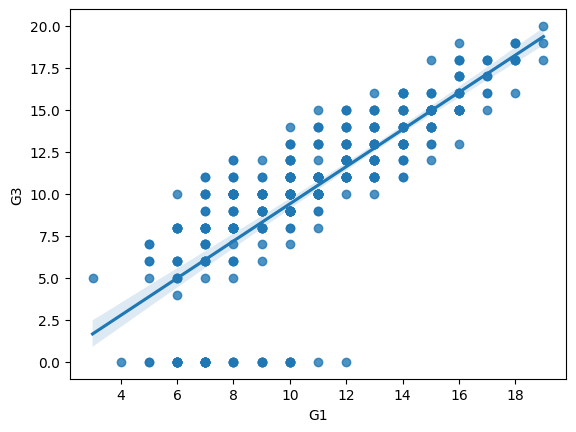

In [ ]:
sns.regplot(data = df1, x='G1',y="G3",order = 1)

<Axes: xlabel='G2', ylabel='G3'>

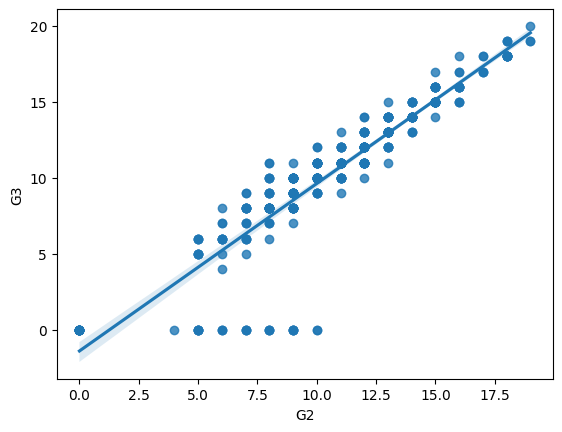

In [ ]:
sns.regplot(data = df1, x='G2',y="G3",order = 1)

<Axes: xlabel='absences', ylabel='G3'>

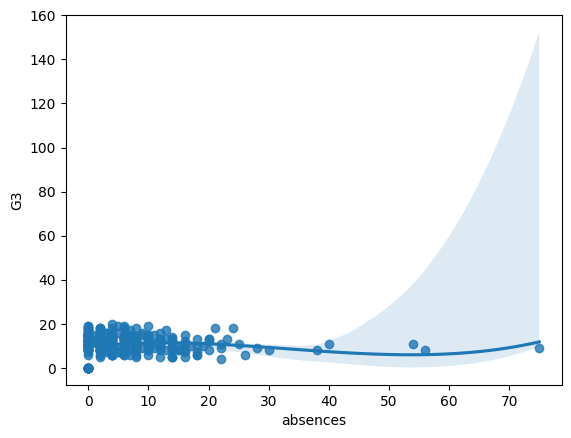

In [ ]:
sns.regplot(data = df1, x='absences',y="G3",order = 3)

<Axes: xlabel='famrel', ylabel='G3'>

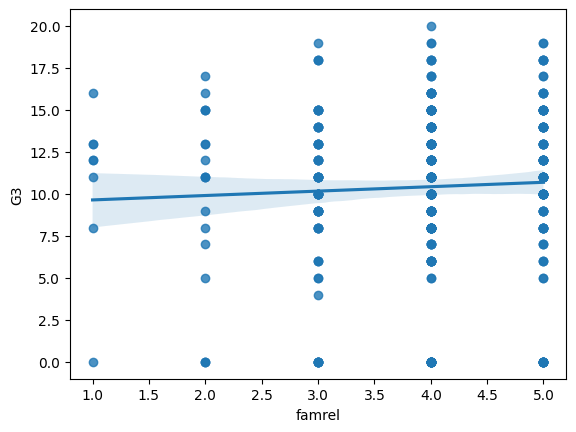

In [ ]:
sns.regplot(data = df1, x='famrel',y="G3",order = 1)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print("MSE:", mean_squared_error(Y_test, y_pred))
print("R^2:", r2_score(Y_test, y_pred))

MSE: 4.163105697228048
R^2: 0.7969716605476179


In [ ]:
errors = Y_test - y_pred

In [ ]:
comparison = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual  Predicted
0      10   7.084940
1      12  12.052615
2       5   3.552248
3      10   8.691439
4       9   8.966179
5      13  12.257174
6      18  18.785667
7       6   6.514181
8       0   7.370985
9      14  12.548848


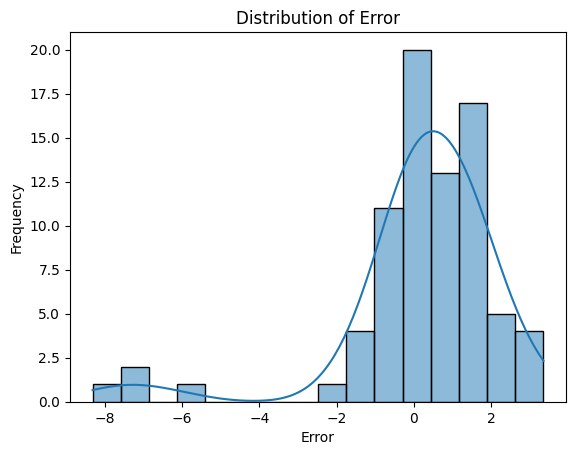

In [ ]:
sns.histplot(errors, kde=True)
plt.title("Distribution of Error")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()